# Interpolation entre mesures de probabilités
 By Victor Ducros & Georgii Potoshin

# 1. Interpolation(s) entre deux mesures de probabilités


La première façon d'interpoler est en variables aléatoires. Donc, on pose pour deux v.a.i. $X_0 \sim \mu_0$, $X_1 \sim \mu_1$ : $X_t :=(1-t)X_0+tX_1$.


[T1] Si $X_0$ et $X_1$ admettent des densités $f_0$ et $f_1$, une question naturelle est de calculer la densité de $X_t$.

En passant par la méthode de la fonction muette, on prend $g$ une fonction continue bornée :
$$
\mathbb{E}(g(X_t)) = \mathbb{E}(g(h(X_0, X_1))) \quad \text{où } h(x_0, x_1) = (1 - t)x_0 + t x_1.
$$

Donc, par indépendance de $X_0$ et $X_1$ :
$$
\mathbb{E}(g(X_t)) = \int_{\mathbb{R}} \int_{\mathbb{R}} g((1 - t)x_0 + t x_1) \, f_0(x_0) \, f_1(x_1) \, dx_0 \, dx_1.
$$

On effectue le changement de variable : $x = (1 - t)x_0 + t x_1$, à $x_0$ fixé.

On a :
$$
x_1 = \frac{1}{t} \left( x - (1 - t)x_0 \right),
$$
$$
dx = t \, dx_1 \quad \Rightarrow \quad dx_1 = \frac{dx}{t}.
$$

Donc :
$$
\mathbb{E}(g(X_t)) = \int_{\mathbb{R}} \left( \int_{\mathbb{R}} g(x) \, f_0(x_0) \, f_1\left( \frac{x - (1 - t)x_0}{t} \right) \, dx_0 \right) \frac{dx}{t}.
$$

Ce qui peut s'écrire :
$$
\mathbb{E}(g(X_t)) = \int_{\mathbb{R}} g(x) \left( \frac{1}{t} \int_{\mathbb{R}} f_0(x_0) \, f_1\left( \frac{x - (1 - t)x_0}{t} \right) \, dx_0 \right) dx.
$$

Donc, par définition, la densité $f_t(x)$ est donnée par :
$$
f_t(x) = \frac{1}{t} \int_{\mathbb{R}} f_0(x_0) \, f_1\left( \frac{x - (1 - t)x_0}{t} \right) \, dx_0 \quad \forall x \in \mathbb{R}.
$$
Cette densité est valable $\forall t \in ]0,1]$. Si $t=0$, on a $f_t=f_0$

[S1] Nous pouvons ainsi visualiser des densités pour différentes lois $X_0$ et $X_1$.

In [110]:
import numpy as np
import matplotlib as mplib
import matplotlib.pyplot as plt
import numpy.random as npr
import scipy.stats as sps
import scipy.integrate as spi
from scipy.stats import norm, uniform, expon
from scipy.interpolate import CubicSpline

class Context:
    Lx: np.ndarray
    Lt: list[float]
    axes: mplib.axes._axes.Axes
    plt_count: int
    is_making_legend: bool

    def __init__(self, Lx: np.ndarray, Lt: list[float], a, b):
        self.Lx = Lx
        self.Lt = Lt
        self.plt_count = 0
        self.is_making_legend = True
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        self.axes = axes.ravel()

    def next_axe(self):
        ax = self.axes[self.plt_count]
        self.plt_count += 1
        return ax

    def reset(self, a, b):
        self.plt_count = 0
        fig, axes = plt.subplots(a, b, figsize=(18, 5))
        self.axes = axes.ravel()

    def end_axe(self, ax, name):
        ax.grid(True, alpha=0.3)
        ax.set_title(name)
        if self.is_making_legend:
            ax.legend(loc="upper right", fontsize=8)

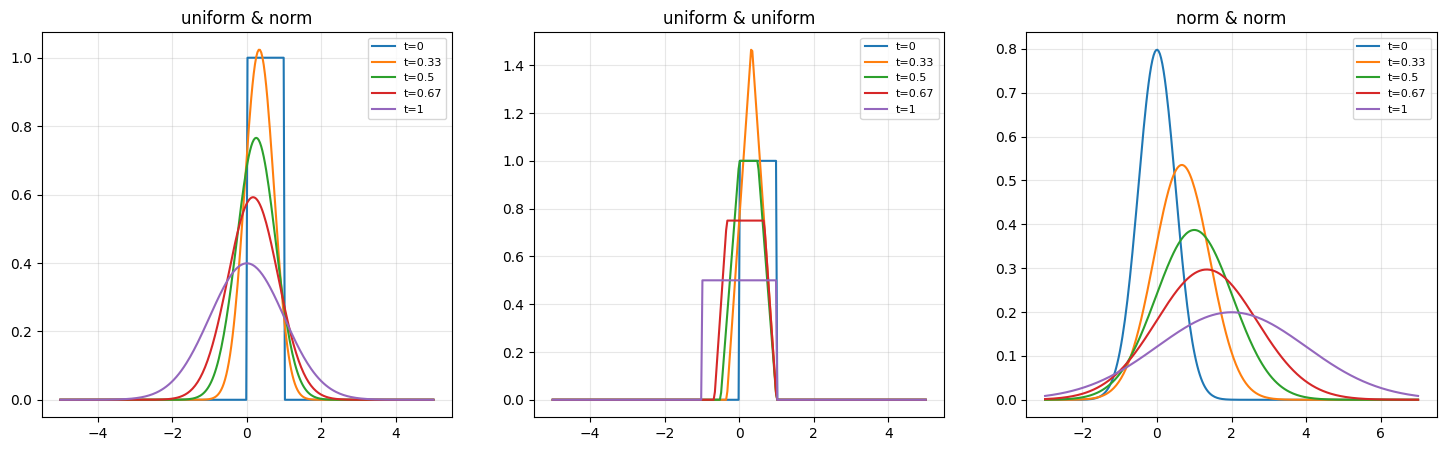

In [111]:
ctx = Context(
    np.linspace(-5,5,300),
    [0,1/3,1/2,2/3,1],
    1,
    3,
)

def va_inter(ctx, f, g, name, a=-np.inf, b=+np.inf):
    ax = ctx.next_axe()
    ax.plot(ctx.Lx, f.pdf(ctx.Lx),label="t=0")
    for t in ctx.Lt[1:]:
        integrale, _ = spi.quad_vec(lambda x0: f.pdf(x0)*g.pdf((ctx.Lx-(1-t)*x0)/t), a, b)
        res = (1/t) * integrale
        ax.plot(ctx.Lx, res, label="t=" + str(round(t, 2)))
    ctx.end_axe(ax, name)


va_inter(ctx, uniform, norm, "uniform & norm", a=0, b=1)
va_inter(ctx, uniform, uniform(loc=-1, scale=2), "uniform & uniform", a=0, b=1)

ctx.Lx = np.linspace(-3,7,300)
va_inter(ctx, norm(loc=0, scale=0.5), norm(loc=2, scale=2), "norm & norm")

plt.show()

[T2]
1. Famille des mesures de Dirac

    La famille des mesures de Dirac est close par cette opération. En effet,
    si on a $f_x, f_y:M\rightarrow\mathbb R$ les v.a. de mesures image $\delta_x, \delta_y$
    on a évidemment $\mathbb P(tf_y+(1-t)f_x = ty+(1-t)x)=1$, comme $f_y^{-1}[y]\cap
    f_x^{-1}[x]$ est de mesure 1, et donc on a pour mesure image $\delta_{tx+(1-t)y}$.

2. Famille des mesures uniformes

    Les mesures uniformes sur un intervalle ne sont pas closes. En effet, si $X$, $Y$
    suivent $U([0,1])$ et qu'on regarde $Z=(X+Y)/2$, un calcule du la fonction de densité
    donne
    \begin{align*}
        \mathbb E f(Z)&=\int f((x+y)/2)\chi_{[0,1]}(x)\chi_{[0,1]}(y)dxdy\\
        &=\int f(z)\chi_{[0,1]}(x)\chi_{[x/2, (x+1)/2]}(z)dx 2dz\\
        &=\int f(z)\left(\int\chi_{[0,1]}(x)\chi_{[x/2, (x+1)/2]}(z)dx\right)2dz\\
        &=\int f(z)\left(\int\chi_{[0,1]}(x)\chi_{[2z-1, 2z]}(x)dx\right)2dz
    \end{align*}
    La fonction de densité est donc donnée $d(z) = 2\int\chi_{[0,1]}(x)\chi_{[2z-1, 2z]}(x)dx$,
    et comme on sait que $Z\in[0,1]$, on devrait avoir $d(z)=1$ sur $[0,1]$, mais
    déjà $d$ n'est pas constante.

3. Famille des mesures Gaussiennes


   Et finalement, les mesures Gaussiennes sont closes
   par cette opération et cela fait partie de la théorie de notre cours.


Considérons maintenant une seconde façon naturelle d’interpoler, qui consiste simplement à poser
$\eta_t =(1-t)\mu_0+t\mu_1$ pour $t\in[0,1]$.

[T3] Soient $U\sim \mathcal U([0,1])$, $X_0\sim\mu_0$ et $X_1\sim\mu_1$ des v.a.i. Posons $Y_t = 1_{U>t}X_0+1_{U\leq t}X_1$. Regardons la forme associée, où par indépendance des variables on peut factoriser le produit tensoriel des mesures.
\begin{align*}
\mathbb E h(Y_t) &= \int h(1_{u>t}x+1_{u\leq t}y) d\mu_0(x)d\mu_1(y)du \\
                 &= \int_{u>t}h(x)d\mu_0(x)du+\int_{u\leq t}h(y)d\mu_1(y)du\\
                 &= \int h(x)(1-t)d\mu_0(x)+\int h(x)td\mu_1(x)\\
                 &= \int h(x) d((1-t)\mu_0 + t\mu_1)(x)
\end{align*}
Donc $Y_t\sim(1-t)\mu_0 + t\mu_1$

[S2]

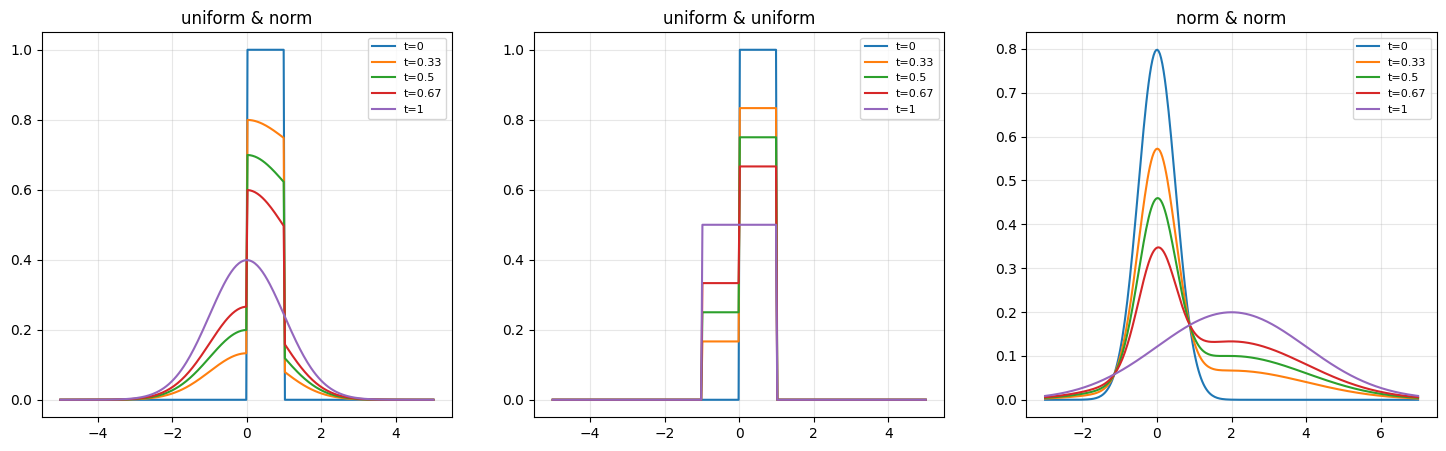

In [105]:
ctx.reset(1, 3) # create display grid 1 x 3
ctx.Lx = np.linspace(-5,5,300)

def meas_inter(ctx, f, g, name):
    ax = ctx.next_axe()
    for t in ctx.Lt:
        ax.plot(ctx.Lx, (1-t)*f.pdf(ctx.Lx) + t*g.pdf(ctx.Lx), label="t="+str(round(t, 2)))
    ctx.end_axe(ax, name)

meas_inter(ctx, uniform, norm, "uniform & norm")
meas_inter(ctx, uniform, uniform(loc=-1, scale=2), "uniform & uniform")

ctx.Lx = np.linspace(-3,7,300)
meas_inter(ctx, norm(scale=0.5), norm(loc=2, scale=2), "norm & norm")
plt.show()

[T4]
1. Famille des mesures de Dirac

    Une mesure de Dirac $\delta_{x_0}$ met un poids 1 sur le point $x_0 \in \mathbb{R}$; or $\eta_t = (1 - t)\delta_{x_0} + td_{x_1}$ met un poids sur deux points différents $x_0$ et $x_1$ (hors cas trivial ou pour $x_0 = x_1$), donc $\eta_t \notin \mathcal{M}_0$, donc les mesures de Dirac ne sont pas préservées par cette opération d'interpolation.

2. Famille des mesures uniformes
    Pour la même raison que pour les mesures de Dirac, prenons par exemple $\rho_0 = U[0,1]$ et $\rho_1 = U[2,3]$ pour $t = \frac{1}{2}$; $\eta_t = \frac{1}{2}U[0,1] + \frac{1}{2}U[2,3]$ n'est pas une mesure uniforme, car $[0,1]$ et $[2,3]$ sont disjoints. Donc la mesure uniforme n'est pas stable.

3. Famille des mesures gaussiennes
Soient $\rho_0 = \mathcal{N}(m_0,\sigma_0^2)$ et $\rho_1 = \mathcal{N}(m_1,\sigma_1^2)$.
$\eta_t = (1 - t)\mathcal{N}(m_0,\sigma_0^2) + t \mathcal{N}(m_1,\sigma_1^2)$; étudions la fonction de densité liée à $Y_t \sim \eta_t$ :

$$
f_{Y_t}(x) = (1 - t)\frac{1}{\sqrt{2\pi}\sigma_0} e^{-\frac{(x - m_0)^2}{2\sigma_0^2}} + t\frac{1}{\sqrt{2\pi}\sigma_1} e^{-\frac{(x - m_1)^2}{2\sigma_1^2}}
$$

Or $f_{Y_t}$ n'est clairement pas une fonction de densité de loi gaussienne, comme dans certains cas elle admet deux maxima locaux, donc $\mathcal{M}_0$ n'est pas conservée.

Introduisons maintenant une troisième interpolation, qui consiste à poser, pour $U\sim \mathcal U([0,1])$,
$$
Z_t =(1-t)F^{-1}_0(U) + tF^{-1}_1 (U)
$$
où $F_i$ est la fonction de répartition de $µ_i$. On note $v_t$ la loi de $Z_t$.

**Théorème de characterisation de fonction de quantile** Si une fonction $Q: ]0,1[\rightarrow \mathbb R$ admet
1. $Q$ est croissante
2. $Q$ est continue à gauche

Alors $Q$ est une fonction de quantile d'une mesure de probabilité de fonction de repartition $F(x)=\sup\{u\in]0,1[\,|\,Q(u)\leq x\}$.

C'est un dual de théorèm de characterisation de fonction de repartition.

1. F est croissante, comme si $x<y$, on a $\{u\in]0,1[\,|\,Q(u)\leq x\}\subseteq \{u\in]0,1[\,|\,Q(u)\leq y\}$, donc $F(x)\leq F(y)$
2. F est continue à droite, comme $u\leq F(x) \leftrightarrow F^{-1}(u)=\inf\{s\,|\,F(s)\geq u\} \leq x$, ainsi $\inf_{t>x} F(t)\geq F(x)$ par croissance, d'autre côté is $\inf_{t>x} F(t) \geq u$, donc pour $t>x$, $t\geq Q(u)$, donc $x\geq Q(u)$, donc $F(x)\geq u$, ainsi $\inf_{t>x} F(t)=F(x)$.
3. Evidement, $\text{lim}_{x\rightarrow \pm\infty}F(x)=0\text{ où }1$

**Corolair** Si $F_i$ sont des fonctions de répartition et $g:R^n\rightarrow R$ est une fonction croissante sur chaque variable et continue à gauche sur chaque variable, donc $g(F_1^{-1},...,F_n^{-1})$ est une fonction de quantile. 

Alors par example une fonciton de quantile de $Z_t$ est $F^{-1}_t=(1-t)F^{-1}_0+tF^{-1}_1$. Ce corolair et consequance nous alons exploiter dans la suite.

[S3] 

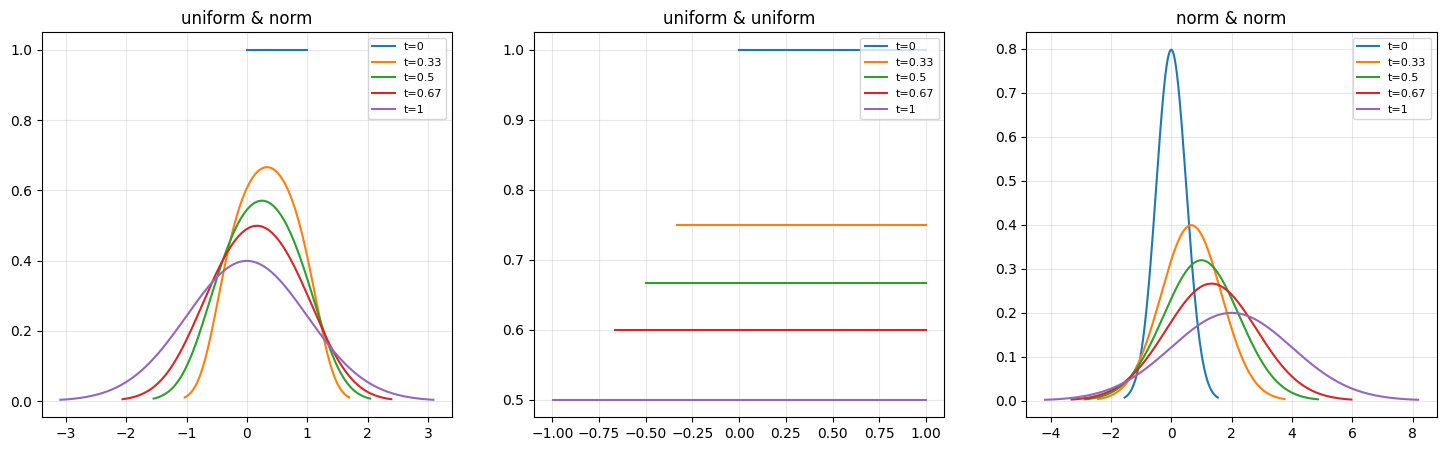

In [106]:
ctx.reset(1, 3)
ctx.Lx = np.linspace(0, 1, 1002)[1:-1] # uniform space without -inf and +inf

def sim_inter(ctx, f, g, name):
    ax = ctx.next_axe()
    for t in ctx.Lt:
        Ly = (1-t)*f.ppf(ctx.Lx)+t*g.ppf(ctx.Lx) # calculating F^{-1}_t
        spline = CubicSpline(Ly, ctx.Lx)         # interpolating F_t
        deriv = spline.derivative()              # approximating f_t = F_t'
        Lx = np.linspace(Ly[0], Ly[-1], 1000)
        ax.plot(Lx, deriv(Lx),label="t="+str(round(t, 2)))
    ctx.end_axe(ax, name)

sim_inter(ctx, uniform, norm, "uniform & norm")
sim_inter(ctx, uniform, uniform(loc=-1, scale=2), "uniform & uniform")
sim_inter(ctx, norm(scale=0.5), norm(loc=2, scale=2), "norm & norm")
plt.show()

[T5] Regardons la stabilité de certaines classes des mesures
1. Famille des mesures de Dirac

   Pour $\delta_{x_0}$, on a :
  $$
  F_0(x') = \begin{cases}
  0 & \text{si } x' < x_0 \\
  1 & \text{si } x' \geq x_0
  \end{cases}
  $$
  La fonction quantile est donc :
  $$
  F_0^{-1}(u) = \inf\{x\in\mathbb R:F_0(x)\geq u\}= x_0 \quad \forall u \in ]0,1]
  $$
  Si $\mu_0 = \delta_{x_0}$ et $\mu_1 = \delta_{x_1}$, alors :
  $$
  Z_t = (1-t)x_0 + t x_1
  $$
  La loi de $Z_t$ est donc $\delta_{(1-t)x_0 + t x_1}$. Cette classe est stable.
2. Famille des mesures uniformes
 
   Pour $\mu_0 = \mathcal{U}([a_0, b_0])$, on a :
   $$
  F_0(x') = \frac{x' - a_0}{b_0 - a_0} \quad \text{pour } x' \in [a_0, b_0]
  $$
  La fonction quantile est :
  $$
  F_0^{-1}(u) = a_0 + u(b_0 - a_0) \quad \forall u \in [0,1]
  $$
  Si $\mu_0 = \mathcal{U}([a_0, b_0])$ et $\mu_1 = \mathcal{U}([a_1, b_1])$, alors :
  \begin{align*}
  Z_t &= (1-t)(a_0 + U(b_0 - a_0)) + t(a_1 + U(b_1 - a_1))\\
      &= (1-t)a_0 + t a_1 + U \left[(1-t)(b_0 - a_0) + t(b_1 - a_1)\right]
  \end{align*}
  Comme $U \sim \mathcal{U}([0,1])$, on a :
  $$
  Z_t \sim \mathcal{U}\left([(1-t)a_0 + t a_1, (1-t)b_0 + t b_1]\right)
  $$
  La famille des mesures uniformes est stable.
3. Famille des mesures Gaussiennes

    Pour $\mu_0 = \mathcal{N}(m_0, \sigma_0^2)$, on a :
  $$
  F_0(x) = \Phi\left(\frac{x - m_0}{\sigma_0}\right)
  $$
  où $\Phi$ est la fonction de répartition de $\mathcal{N}(0,1)$. La fonction quantile est :
  $$
  F_0^{-1}(u) = m_0 + \sigma_0 \Phi^{-1}(u) \quad \forall u \in [0,1]
  $$
  Si $\mu_0 = \mathcal{N}(m_0, \sigma_0^2)$ et $\mu_1 = \mathcal{N}(m_1, \sigma_1^2)$, alors :
  \begin{align*}
  Z_t &= (1-t)(m_0 + \sigma_0 \Phi^{-1}(U)) + t(m_1 + \sigma_1 \Phi^{-1}(U))\\
  &= (1-t)m_0 + t m_1 + \left[(1-t)\sigma_0 + t \sigma_1\right] \Phi^{-1}(U)
  \end{align*}
  Comme $\Phi^{-1}(U) \sim \mathcal{N}(0,1)$, on a :
  $$
  Z_t \sim \mathcal{N}\left((1-t)m_0 + t m_1, \left[(1-t)\sigma_0 + t \sigma_1\right]^2\right)
  $$

La famille des mesures Gaussiennes est stable.

[T6]
1. Par linéarité $\mathbb E((1-t)X_0+tX_1)= (1-t)\mathbb EX_0 + t\mathbb EX_1$. Pour $η_t = (1−t)µ_0 + tµ_1$ nous avons $\mathbb EX_t=\int xd(t\mu_1+(1-t)\mu_0)=t\int xd\mu_1+(1-t)\int xd\mu_0$, car les mesures forment l'éspace dual des fonctions continues à support compact, avec l'action – prendre l'integrale. Et finalement pour $Z_t = (1−t)F^{−1}_0(U)+tF^{−1}_1(U)$ on passe par le même argument que dans le premièr cas, car $F^{-1}_i(U)$ suit le même loi que $X_i$. Alors ces interpolations commutent avec $\mathbb E$.

2. Supposons que $\mu_0=\mu_1$. Qu peut-on dire des interpolations? Dans le premier type d'interpolation on utilise le même exemple que dans [T2] est voit que, $\mu_t\neq\mu_0$. Pour deuxieme methode, on a $\mu=(1-t)\mu_0+t\mu_0=\mu_0$. Est dans troisième example, on a $F_0 = F_1 =: F$ et donc, on a $F^{-1}(U)=X_t = X_0$, donc on a la même mesure image.

3. Maintenent, on vérifie que la convergence est continue en loi. C'est evident pour la deuxiem interpolation, en loi
$$
\mathbb Eh(X_t) = (1-t)\mathbb Eh(X_0)+t\mathbb Eh(X_1)
$$
les 2 autres methodes sont continue. En effet, pour deux fonctions mesurables $X_0$ et $X_1$ et une fonction continue de support compact $h$, nous avons $h((1-t)X_0(w)+tX_1(w))$ continues en t et $|h|\leq C$ pour une constante $C$, on peut donc applique le théorème de convergence domminée et voir que
$$
    \mathbb Eh(X_t) = \int h((1-t)X_0(w)+tX_1(w))dw
$$
est continue en $t$.

[S4] Il faut preciser que le choix de $Y_t$ pour $\eta_t$ dans l'exercice $T3$ n'est pas unique et donc, en traçant les chemains pour $Y_t$, on ne les trace pas pour $\eta_t$, mais on trace differentes realisations de $X_t$, $Y_t$, $Z_t$ pour des événements élémentairs $w$, comme c'est démandé dans l'exercice. 

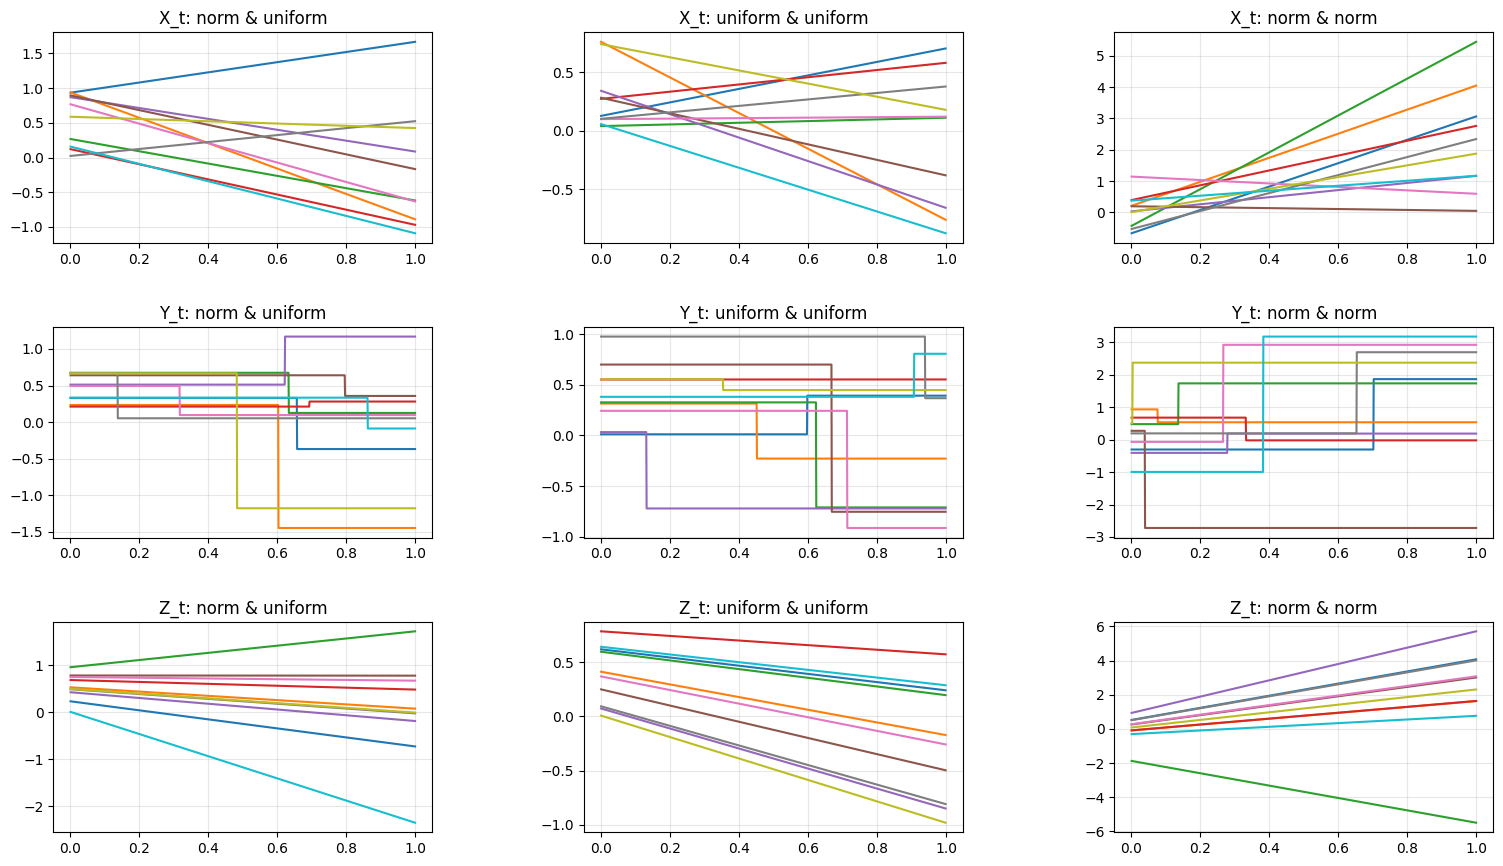

In [107]:
def trace_line(ctx, ax, a, b):
    Ly = (1 - ctx.Lx) * a + ctx.Lx * b
    ax.plot(ctx.Lx, Ly)

def make_10_traj_var_inter(ctx, f, g, name):
    ax = ctx.next_axe()
    for i in range(10):
        a, b = f.rvs(), g.rvs()
        trace_line(ctx, ax, a, b)
    ctx.end_axe(ax, name)

def make_10_traj_meas_inter(ctx, f, g, name):
    ax = ctx.next_axe()
    for i in range(10):
        u = uniform.rvs()
        a, b = f.rvs(), g.rvs()
        Ly = np.where(u > ctx.Lx, a, b)
        ax.plot(ctx.Lx, Ly)
    ctx.end_axe(ax, name)

def make_10_traj_sim_inter(ctx, f, g, name):
    ax = ctx.next_axe()
    for i in range(10):
        u = uniform.rvs()
        a, b = f.ppf(u), g.ppf(u)
        trace_line(ctx, ax, a, b)
    ctx.end_axe(ax, name)
    
ctx.reset(3,3)
ctx.is_making_legend = False
make_10_traj_var_inter(ctx, uniform, norm, "X_t: norm & uniform")
make_10_traj_var_inter(ctx, uniform, uniform(loc=-1, scale=2), "X_t: uniform & uniform")
make_10_traj_var_inter(ctx, norm(scale=0.5), norm(loc=2, scale=2), "X_t: norm & norm")

make_10_traj_meas_inter(ctx, uniform, norm, "Y_t: norm & uniform")
make_10_traj_meas_inter(ctx, uniform, uniform(loc=-1, scale=2), "Y_t: uniform & uniform")
make_10_traj_meas_inter(ctx, norm(scale=0.5), norm(loc=2, scale=2), "Y_t: norm & norm")
    
make_10_traj_sim_inter(ctx, uniform, norm, "Z_t: norm & uniform")
make_10_traj_sim_inter(ctx, uniform, uniform(loc=-1, scale=2), "Z_t: uniform & uniform")
make_10_traj_sim_inter(ctx, norm(scale=0.5), norm(loc=2, scale=2), "Z_t: norm & norm")

plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=1.7, wspace=0.4, hspace=0.4)
plt.show()

[T7] On remarque que $X_t$ et $Z_t$ sont toujours continue, comme elles sont les interpolations affines entre position initial et final, mais $Y_t$ est presque toujours discontinue, comme l'ensemble des evenement, pour lesquels Y_t est continue, est definie par $\{X_0=X_1\}\cup\{U=0\}$ qui est de mesure $0$.

# 2. Distance de Wasserstein

$$
\mathcal W_p(\mu_0,\mu_1)=\left(\int_{]0,1[}|F_0^{-1}-F_1^{-1}|^p\right)^{1/p},\quad\text{où }F_i\text{ est la fonction repartition de }\mu_i
$$
[T8] Comme $F_i^{-1}(U)\sim\mu_i$ et $\mu_i$ est de momment d'ordre $p$, $F_i^{-1}\in L^p$. On remarque que $\mathcal W_p(\mu_0,\mu_1)=\|F_0^{-1}-F_1^{-1}\|_p$, donc c'est bien définit. Comme distance de Wasserstien est déja une distance $L^p$ entre les fonction, pour montrer que $\mathcal W$ est une distance, il ne reste que montrer la séparation, mais on remarque que $\mu$ est definit par cette fonction de repartition (resultat de cours) et donc $\mathcal W$ est une distance.

[T9] Soient $\mu_n\in\mathcal P_p$ on suppose que $\mu_n\rightarrow \mu$ en $\mathcal W_p$, montrons la convergence en loi. On considère $X = F^{-1}(U)$ et $X_n=F_n{-1}(U)$ avec $U \sim \mathcal{U}([0, 1])$.

Pour $p \geq 1$ :
$$
\mathcal{W}_p(\mu, \mu_n)^p = \int_0^1  |F^{-1}(u) - F_n^{-1}(u)| \, du = \mathbb{E}(|X - X_n|^p).
$$

Soit $f$ une fonction Lipschitzienne bornée. Comme l'espace des fonctions Lipschitziennes bornées est $\|\cdot\|_\infty$ dense dans l'espace des fonctions continues bornées, on montre que
$\mathbb{E}(f(X_n)) \to \mathbb{E}(f(X))$ sans perte de généralité.

On sait que $\mathcal{W}_p^p(\mu, \mu_n) \xrightarrow[n \to \infty]{} 0$, donc $\mathbb{E}(|X - X_n|^p) \to 0$.

$$
\begin{array}{l}
 |\mathbb{E}(f(X)) - \mathbb{E}(f(X_n))| = |\mathbb{E}(f(X) - f(X_n))| \\
\leq \mathbb{E}(|f(X) - f(X_n)|)  \\
\leq L \cdot \mathbb{E}(|X - X_n|). \quad \text{(car $f$ est $L$-Lipschitzienne, avec $L \in \mathbb{R}$)}
\end{array}
$$

Comme $x \mapsto x^p$ est convexe sur $\mathbb{R}$ si $p \geq 1$, alors d'après l'inégalité de Jensen :
$$
\mathbb{E}(|X - X_n|) \leq \left( \mathbb{E}(|X - X_n|^p) \right)^{\frac{1}{p}}.
$$

Donc
$$
 |\mathbb{E}(f(X)) - \mathbb{E}(f(X_n))| \leq L \cdot \left( \mathbb{E}(|X - X_n|^p) \right)^{\frac{1}{p}} \xrightarrow[n \to +\infty]{} 0.
$$

Donc $\mathbb{E}(f(X_n)) \xrightarrow[n \to +\infty]{} \mathbb{E}(f(X))$ pour les fonctions Lipschitziennes bornées, donc par densité pour les fonctions continues et bornées.

Ainsi $X_n \xrightarrow{\mathcal{L}} X$.

[T10] On détermine la fonction de répartition de $\mu_0$ :

Soit $x \in \mathbb{R}$ :
$$
F_0(x) = \begin{cases}
0 & \text{si } x < x_{(1)}, \\
\frac{k}{N} & \text{si } x \in [x_k, x_{(k+1)}[ \text{ pour } k \in [\![1, N-1]\!], \\
1 & \text{si } x \geq x_{(N)}.
\end{cases}
$$

Ainsi, la fonction quantile inverse de $F_0$ est :

Soit $u \in [0, 1[$,
$$
F_0^{-1}(u) = x_{(k)} \quad \text{si } u \in \left[\frac{k-1}{N}, \frac{k}{N}\right[ \text{ avec } k \in [\![ 1, N]\!].
$$

On a la même expression pour $\mu_1$ avec les $y_k$.

Donc
$$
\begin{aligned}
\mathcal{W}_p^p(\mu_0, \mu_1) &= \int_0^1 |F_0^{-1}(u) - F_1^{-1}(u)|^p \, du \\
&= \sum_{k=1}^N \left( \int_{\frac{k-1}{N}}^{\frac{k}{N}} |x_{(k)} - y_{(k)}|^p \, du \right) \\
&= \sum_{k=1}^N \frac{1}{N} |x_{(k)} - y_{(k)}|^p.
\end{aligned}
$$

$$
\mathcal{W}_p^p(\mu_0, \mu_1) = \frac{1}{N} \sum_{k=1}^N |x_{(k)} - y_{(k)}|^p.
$$

[S5]

In [108]:
N = 1000
p = 2

mean_0_thr  = 0
sigma_0_thr = 1
mean_1_thr  = 1
sigma_1_thr = 1

X = np.sort(norm(mean_0_thr, sigma_0_thr).rvs(N))
Y = np.sort(norm(mean_1_thr, sigma_1_thr).rvs(N))

W2_empirical = np.sqrt(np.sum((1/N)*np.pow(X-Y, 2)))

W2_theoretical = np.sqrt((mean_1_thr - mean_0_thr)**2 + (sigma_1_thr - sigma_0_thr)**2)

print(f"Valeur empirique de W2 : {W2_empirical:.4f}")
print(f"Valeur théorique de W2 : {W2_theoretical:.4f}")


Valeur empirique de W2 : 1.0163
Valeur théorique de W2 : 1.0000


[T11]
Si $F_i^{-1}$ sont $L^p$, donc $(1-t)F_0^{-1} + tF_1^{-1}$ l'est aussi. De plus $(1-t)F_0^{-1} + tF_1^{-1}$ est une fonction de repartition de $\nu_t$.
$$
\mathcal W_p(\nu_t, \nu_s)^p = \int |(1-t)F_0^{-1} + tF_1^{-1} - (1-s)F_0^{-1} - sF_1^{-1}|^p = \int|(t-s)(F_1^{-1}-F_0^{-1})|^p=|s-t|^p\mathcal W_p(\mu_0, \mu_1)^p
$$
Donc $\nu_t$ est une géodesique.

[T12] On remarque que $\mu_t$ n'est pas une géodesique en général, comme pour $\mu_0,\mu_1\sim\mathcal U([0,1])$, on a $\mu_{0.5}\neq \mu_0$ (exo T2)

[S6]

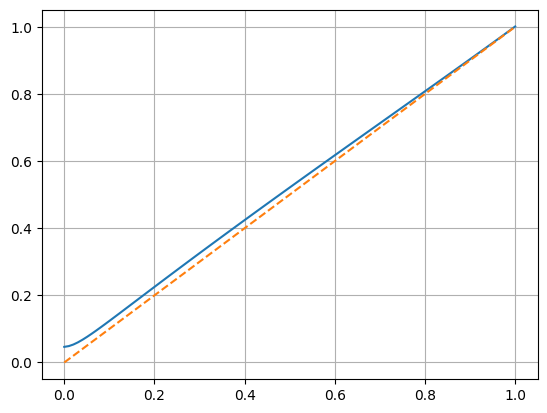

In [116]:
N = 5000
grid_x = np.linspace(-5, 6, 2000)
pdf0 = norm.pdf(grid_x, 0, 1)
pdf1 = norm.pdf(grid_x, 1, 1)

X = np.sort(norm(0, 1).rvs(N))
u = np.sort(np.random.uniform(0, 1, N))
Lt = np.linspace(0, 1, 100)
Ly = []

for t in Lt:
    cdf_t = np.cumsum((1 - t) * pdf0 + t * pdf1)
    Y_t = np.interp(u, cdf_t / cdf_t[-1], grid_x)
    Ly.append(np.sqrt(np.mean((X - Y_t) ** 2)))

plt.plot(Lt, Ly)
plt.plot(Lt, Lt , "--")
plt.grid()
plt.show()

Alors dans ce cas c'est une géodésique.

# 3. Barycentre d’un ensemble de mesures de probabilité

[T13]

On a $ X_i - Y = (X_i - \bar{X}) + \bar{X} - Y $

Ainsi,
\begin{aligned}
\mathbb{E}[(X_i - Y)^2] &= \mathbb{E}[(X_i - \bar{X} + \bar{X} - Y)^2]\\
                        &= \mathbb{E}[(X_i - \bar{X})^2 + 2(X_i - \bar{X})(\bar{X} - Y) + (\bar{X} - Y)^2] \\
                        &= \mathbb{E}[(X_i - \bar{X})^2] + 2\mathbb{E}[(X_i - \bar{X})(\bar{X} - Y)] + \mathbb{E}[(\bar{X} - Y)^2]. \\
\end{aligned}

Or,
\begin{aligned}
\sum_{i=1}^{n} \mathbb{E}[(X_i - \bar{X})(\bar{X} - Y)] &= \mathbb{E}\left[\sum_{i=1}^{n}(X_i - \bar{X})(\bar{X} - Y)\right] \\
                                                        &= \mathbb{E}[(\bar{X} - Y)\left(\sum_{i=1}^{n}X_i - n\bar{X}\right)] \\
                                                        &= \mathbb{E}[(\bar{X} - Y)(n\bar{X} - n\bar{X})] \\
                                                        &= \mathbb{E}[0] = 0. \\
\end{aligned}

Donc, $$J(Y) = \sum_{i=1}^{n}\mathbb{E}[(X_i - \bar{X})^2] + \sum_{i=1}^{n}\mathbb{E}[(\bar{X} - Y)^2] = J(\bar{X}) + \underbrace{\sum_{i=1}^{n}\mathbb{E}[(\bar{X} - Y)^2]}_{> 0}$$

Donc $J(Y) \geq J(\bar{X})$ pour tout $Y$, avec égalité seulement si $Y = \bar{X}$ presque sûrement.
Ainsi, $\bar{X}$ est l'unique minimiseur de $J$.


[T14]

$$
J(\nu) = \sum_{i=1}^{n} W_{2}^{2}(p_{i}, \nu)
= \sum_{i=1}^{n} \int_{0}^{1} |F_{i}^{-1}(u) - F_{\nu}^{-1}(u)|^{2} \, du
= \sum_{i=1}^{n} \mathbb{E}[|F_{i}^{-1}(U) - F_{\nu}^{-1}(U)|^{2}]
= J( F_{\nu}^{-1})
$$

Pour $X_{i} = F_{i}^{-1}(U)$, où $U \sim \mathcal{U}([0,1])$

$Y$ a pour fonction de répartition $F_{\nu}$, celle de $\nu$.

Donc $J(v) = J(Y) = \sum_{i=1}^{n} \mathbb{E}[(X_{i} - Y)^2]$.

D'après la question **T13**, l'unique minimiseur de $J$ est :
$$
Z = \frac{1}{n} \sum_{i=1}^{n} X_{i} = \frac{1}{n} \sum_{i=1}^{n} F_{i}^{-1}(U).
$$

$Z = F_{\nu}^{-1}(U)$, donc la loi de $\nu$ qui minimise $J$ est bien celle de $Z$.

[T15] On note Z la baricentre de l'absentain.

1. Pour $\mathcal{M}_D$

    On note $\forall i\in[1,n]$ $p_i = \delta_{\alpha_i}$ avec $\alpha_i\in\mathbb{R}$.

    D'après la question T5 en notant $F_i$ la fonction de népantition de $p_i$ on a $\forall u\in[0,1]$ $F_i^{-1}(u) = \alpha_i$.

    Ainsi $\frac{1}{n}\sum_{i=1}^{n}F_i^{-1}(u) = \frac{1}{n}\sum_{i=1}^{n}\alpha_i$.

    Donc $\hat{u} \sim\delta_{\frac{1}{n}\sum_{i=1}^{n}x}$.

2. Pour $\mathcal{M}_u$

    On note $\forall i\in[1,n]$, $p_i = U([a_i, b_i])$ $a_i<b_i$.

    D'après la question T5 $\forall u\in[0,1]$, $F_i^{-1}(u) = a_i + u(b_i - a_i)$.

    Ainsi $\frac{1}{n}\sum_{i=1}^{n}F_i^{-1}(u) = \frac{1}{n}\sum_{i=1}^{n}(a_i + u(b_i - a_i)) = \frac{1}{n}\sum_{i=1}^{n}a_i + u\left(\frac{1}{n}\sum_{i=1}^{n}b_i - \frac{1}{n}\sum_{i=1}^{n}a_i\right)$.

    Donc $\hat{u} \sim U\left[\frac{1}{n}\sum_{i=1}^{n}a_i, \frac{1}{n}\sum_{i=1}^{n}b_i\right]$.

3. Pour $\mathcal{M}_G$

    On note $\forall i\in[1,n]$, $p_i = \mathcal{N}(m_i, \sigma_i^2)$.

    D'après la question T5 $\forall u\in[0,1]$, $F_i^{-1}(u) = m_i + \sigma_i \phi^{-1}(u)$ avec $\phi$ la fonction de répantition de $\mathcal{N}(0,1)$.

    Ainsi $\frac{1}{n}\sum_{i=1}^{n}F_i^{-1}(u) = \frac{1}{n}\sum_{i=1}^{n}(m_i + \sigma_i \phi^{-1}(u)) = \frac{1}{n}\sum_{i=1}^{n}m_i + \phi^{-1}(u) \times \frac{1}{n}\sum_{i=1}^{n}\sigma_i$.

    Donc $\hat{u} \sim\mathcal{N}\left(\frac{1}{n}\sum_{i=1}^{n}m_i, \left(\frac{1}{n}\sum_{i=1}^{n}\sigma_i\right)^2\right)$.

NameError: name 'expon' is not defined

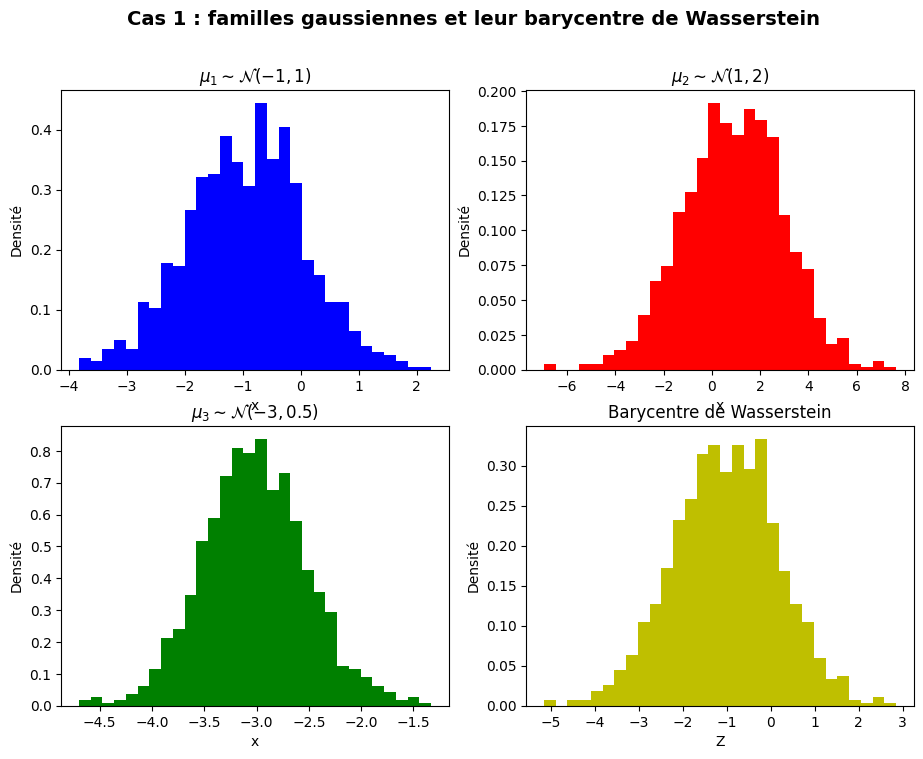

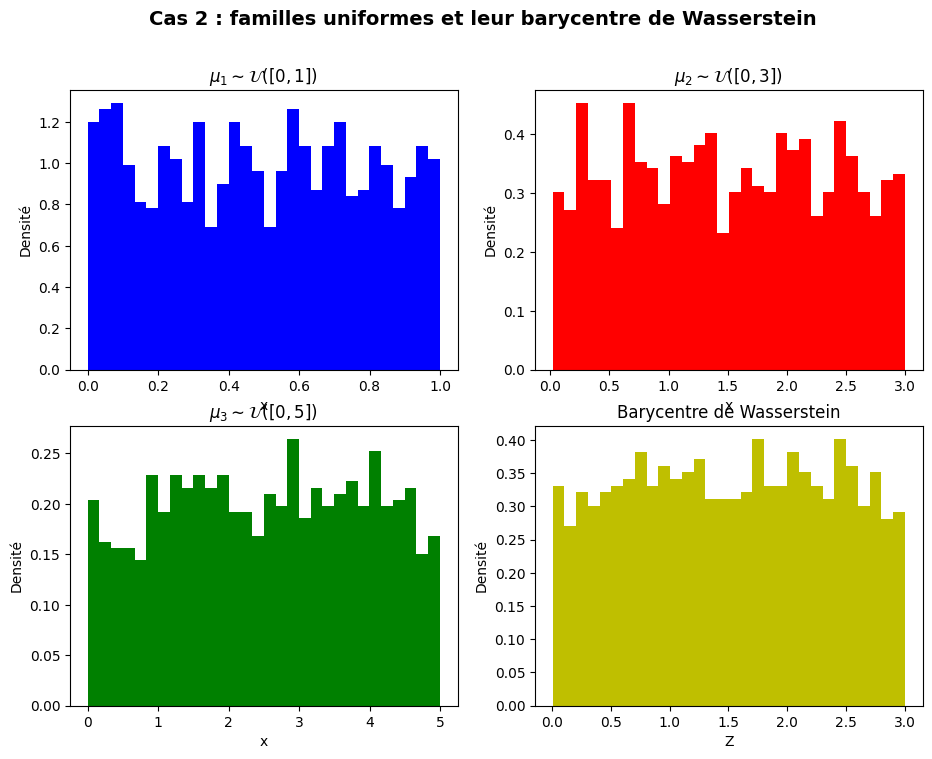

In [109]:
N=1000
def wasserstein_barycenter_empirical(families):
    n = len(families)
    z = np.zeros(N)
    # Moyenne ponderee
    for f in families:
        z += (1/n) * f
    return z


def barycenter(familie1,familie2,familie3,labels,title):
    X1 = np.sort(familie1.rvs(N))
    X2 = np.sort(familie2.rvs(N))
    X3 = np.sort(familie3.rvs(N))
    families=[X1,X2,X3]
    Z=wasserstein_barycenter_empirical([X1,X2,X3])
    
    #tracés
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    axes = axes.ravel()
    colors = ["b", "r", "g"]
    #tracé des différentes lois
    for ax, x, label, color in zip(axes[:3], families, labels, colors):
        ax.hist(x,bins=30, color=color,density=True)
        ax.set_title(label)
        ax.set_xlabel("x")
        ax.set_ylabel("Densité")
    #tracé du barycentre
    axes[3].hist(Z,bins=30, color="y",density=True)
    axes[3].set_title("Barycentre de Wasserstein")
    axes[3].set_xlabel("Z")
    axes[3].set_ylabel("Densité")
    fig.suptitle(title, fontsize=14, fontweight="bold")

barycenter(norm(loc=-1, scale=1),norm(loc=1, scale=2),norm(loc=-3,scale=0.5),
           [r"$\mu_1 \sim \mathcal{N}(-1,1)$",
         r"$\mu_2 \sim \mathcal{N}(1,2)$",
         r"$\mu_3 \sim \mathcal{N}(-3,0.5)$"],
        "Cas 1 : familles gaussiennes et leur barycentre de Wasserstein"
          )

barycenter(uniform(loc=0,scale=1),uniform(loc=0,scale=3),uniform(loc=0,scale=5),
           [r"$\mu_1 \sim \mathcal{U}([0,1])$",
         r"$\mu_2 \sim \mathcal{U}([0,3])$",
         r"$\mu_3 \sim \mathcal{U}([0,5])$"],
        "Cas 2 : familles uniformes et leur barycentre de Wasserstein")

barycenter(norm(loc=0,scale=1),uniform(loc=-1,scale=2),expon(scale=1),
          [r"$\mu_1 \sim \mathcal{N}(0,1)$",
         r"$\mu_2 \sim \mathcal{U}([-1,1])$",
         r"$\mu_3 \sim \mathcal{E}(1)$"],
        "Cas 3 : melange gaussienne / uniforme / exponentielle "
        "et leur barycentre de Wasserstein")

